# LendingClub Credit Risk Model — v2

**Predicting loan default and converting that prediction into a profit-maximizing lending policy.**

A modernized rewrite of [*Lending Club Loan Defaulters Prediction*](https://www.kaggle.com/code/faressayah/lending-club-loan-defaulters-prediction), extended into an end-to-end credit-risk study.

Self-contained — every function is defined inline, no external package required.

---

## What changed from v1 (and why)

v1 scored ROC-AUC 0.722 / KS 0.324, which is a solid model. But three things were wrong or missing:

| # | Issue in v1 | Fix in v2 |
|---|---|---|
| 1 | **Calibration broke the threshold.** The operating threshold was tuned on *raw* probabilities, then applied to *calibrated* ones. Since calibration rescales the whole distribution, recall collapsed 0.745 → 0.151 and approval rate jumped to 94.4%. | Threshold is **re-optimized on calibrated validation scores**. Never reuse a threshold across a probability rescaling. |
| 2 | **LightGBM was crippled by three separate issues.** It early-stopped on `binary_logloss` (which `scale_pos_weight` distorts); it kept watching that default metric even when given another; and `subsample=0.8` did nothing at all, because LightGBM ignores it unless `subsample_freq > 0`. Net effect: AUC 0.703 vs XGBoost's 0.722, with a suspiciously *better* Brier, which is the tell that it had barely trained. | `eval_metric="average_precision"` + `first_metric_only=True` + `subsample_freq=1`. |
| 3 | **No baseline.** Nothing showed the model beat LendingClub's existing `sub_grade` system — which is the first question any reviewer asks. | Added three baselines: approve-everyone, **LendingClub sub_grade**, and logistic regression. |

## What's new in v2

- **Dollar-based profit optimization** — replaces the abstract 5:1 cost ratio with real loan economics (interest earned vs. principal lost), producing an actual currency figure for the policy
- **Baseline comparison** — including LendingClub's own risk grades as the incumbent to beat
- **Temporal validation** — trains on older vintages, tests on newer, to check the model survives time
- **Segment analysis** — performance broken out by grade, term, and purpose, to find where the model is weak
- **Optional Optuna tuning**
- **A full results bundle** written to `/kaggle/working/` for writing up the project

## Business framing

Two asymmetric errors:
- **Approve a borrower who defaults** → lose most of the principal
- **Reject a borrower who would have repaid** → lose the interest margin

Because these costs differ by roughly an order of magnitude, the decision threshold matters as much as the model. v2 makes that explicit in dollars.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss,
    classification_report, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

import xgboost as xgb
import lightgbm as lgb

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)
%matplotlib inline

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# ---- run switches -------------------------------------------------------
RUN_TUNING     = False   # Optuna search (adds ~10-20 min)
RUN_TEMPORAL   = True    # out-of-time validation
TUNING_TRIALS  = 25
SHAP_SAMPLE    = 2000

# ---- loan economics (used for the profit curve) --------------------------
# LGD = loss given default: the share of principal actually lost after
# partial repayments and recoveries. LendingClub recoveries on charged-off
# loans are low; 0.60 is a deliberately conservative mid-range assumption.
# Every dollar figure below scales with this - change it and re-read.
LGD = 0.60
print("Setup complete.")

Setup complete.


In [2]:
# Locate the dataset (searches /kaggle/input so the path isn't hardcoded)
CSV_PATH = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        hits = list(root.rglob("lending_club_loan_two.csv"))
        if hits:
            CSV_PATH = hits[0]; break
if CSV_PATH is None:
    raise FileNotFoundError("Attach the LendingClub dataset via 'Add Input', or set CSV_PATH manually.")

print(f"Dataset: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
MODELS_DIR = OUTPUT_DIR / "models"
REPORTS_DIR = OUTPUT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
for d in (MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

RESULTS = {}   # collects every headline number for the final write-up

Dataset: /kaggle/input/datasets/jeandedieunyandwi/lending-club-dataset/lending_club_loan_two.csv
396,030 rows x 27 columns


## 2. Feature engineering

Same logic as v1, with one addition: `issue_d` is parsed into a vintage year **before** being dropped. It is never used as a model feature — it's held aside purely so we can do an out-of-time split in section 8.

In [3]:
TARGET_COL = "loan_status"
LEAKAGE_COLS = ["issue_d"]
LOW_VALUE_COLS = ["emp_title", "emp_length", "title", "grade"]
CATEGORICAL_COLS = ["sub_grade", "verification_status", "purpose", "initial_list_status",
                    "application_type", "home_ownership", "term", "state"]

MONTHS = {m: i+1 for i, m in enumerate(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])}


def extract_state(a):       return a.str.extract(r",\s*([A-Z]{2})\s*\d{5}")[0].fillna("UNKNOWN")
def extract_term_months(t): return t.astype(str).str.extract(r"(\d+)").astype(int)[0]
def extract_year(s):        return s.astype(str).str.split("-", expand=True)[1].astype(int)
def binarize(s):            return (s.fillna(0) > 0).astype(int)


def issue_date_ordinal(issue_d):
    """'Jan-2015' -> 2015*12+1, a sortable month index used only for the time split."""
    parts = issue_d.astype(str).str.split("-", expand=True)
    return parts[1].astype(int) * 12 + parts[0].map(MONTHS).astype(int)


def fit_mort_acc_lookup(d):   return d.groupby("total_acc")["mort_acc"].mean()
def apply_mort_acc_lookup(d, lookup):
    return d["mort_acc"].fillna(d["total_acc"].map(lookup)).fillna(lookup.mean()).round()


def add_ratio_features(d):
    income = d["annual_inc"].clip(lower=1.0)
    d["loan_to_income"] = d["loan_amnt"] / income
    d["annual_installment_to_income"] = (d["installment"] * 12) / income
    d["revol_bal_to_income"] = d["revol_bal"] / income
    d["open_to_total_acc_ratio"] = d["open_acc"] / d["total_acc"].clip(lower=1.0)
    d["log_annual_inc"] = np.log1p(d["annual_inc"].clip(lower=0))
    d["credit_history_years"] = 2016 - d["earliest_cr_line"]
    d["installment_to_loan"] = d["installment"] / d["loan_amnt"].clip(lower=1.0)
    return d


def clean_and_engineer(df, mort_acc_lookup=None, verbose=True):
    df = df.copy()
    df = df[df[TARGET_COL].isin(["Fully Paid", "Charged Off"])]
    y = df[TARGET_COL].map({"Fully Paid": 0, "Charged Off": 1}).astype(int)

    vintage = issue_date_ordinal(df["issue_d"])     # held aside, never a feature

    df["home_ownership"] = df["home_ownership"].replace(["ANY", "NONE"], "OTHER")
    df["term"] = extract_term_months(df["term"])
    df["state"] = extract_state(df["address"])
    df["earliest_cr_line"] = extract_year(df["earliest_cr_line"])

    lookup = mort_acc_lookup if mort_acc_lookup is not None else fit_mort_acc_lookup(df)
    df["mort_acc"] = apply_mort_acc_lookup(df, lookup)
    df["pub_rec"] = binarize(df["pub_rec"])
    df["pub_rec_bankruptcies"] = binarize(df["pub_rec_bankruptcies"])
    df = add_ratio_features(df)

    # keep sub_grade as an ordinal too - used for the incumbent baseline
    sg_order = [f"{g}{i}" for g in "ABCDEFG" for i in range(1, 6)]
    sub_grade_ord = df["sub_grade"].map({s: i for i, s in enumerate(sg_order)})

    df = df.drop(columns=[c for c in LEAKAGE_COLS + LOW_VALUE_COLS + ["address", TARGET_COL]
                          if c in df.columns])

    before = len(df)
    keep = df.dropna().index
    df, y = df.loc[keep], y.loc[keep]
    vintage, sub_grade_ord = vintage.loc[keep], sub_grade_ord.loc[keep]
    if verbose and before - len(df):
        print(f"Dropped {before-len(df):,} rows ({(before-len(df))/before:.2%}) with residual NaNs.")

    return (df.reset_index(drop=True), y.reset_index(drop=True),
            vintage.reset_index(drop=True), sub_grade_ord.reset_index(drop=True))


def get_feature_lists(X):
    cat = [c for c in CATEGORICAL_COLS if c in X.columns]
    return [c for c in X.columns if c not in cat], cat

In [4]:
X, y, vintage, sub_grade_ord = clean_and_engineer(df)
numeric_cols, categorical_cols = get_feature_lists(X)

RESULTS["n_rows"] = len(X)
RESULTS["default_rate"] = float(y.mean())
RESULTS["n_features_raw"] = X.shape[1]

print(f"Rows: {len(X):,}   Default rate: {y.mean():.2%}")
print(f"Features: {X.shape[1]} ({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)")
X.head()

Dropped 276 rows (0.07%) with residual NaNs.
Rows: 395,754   Default rate: 19.61%
Features: 28 (20 numeric, 8 categorical)


,loan_amnt,term,int_rate,installment,sub_grade,home_ownership,annual_inc,verification_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,state,loan_to_income,annual_installment_to_income,revol_bal_to_income,open_to_total_acc_ratio,log_annual_inc,credit_history_years,installment_to_loan
0,10000.0,36,11.44,329.48,B4,RENT,117000.0,Not Verified,vacation,26.24,1990,16.0,0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0,OK,0.085470,0.033793,0.310846,0.640000,11.669938,26,0.032948
1,8000.0,36,11.99,265.68,B5,MORTGAGE,65000.0,Not Verified,debt_consolidation,22.05,2004,17.0,0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0,SD,0.123077,0.049049,0.309708,0.629630,11.082158,12,0.033210
2,15600.0,36,10.49,506.97,B3,RENT,43057.0,Source Verified,credit_card,12.79,2007,13.0,0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0,WV,0.362310,0.141293,0.278398,0.500000,10.670303,9,0.032498
3,7200.0,36,6.49,220.65,A2,RENT,54000.0,Not Verified,credit_card,2.60,2006,6.0,0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0,MA,0.133333,0.049033,0.101333,0.461538,10.896758,10,0.030646
4,24375.0,60,17.27,609.33,C5,MORTGAGE,55000.0,Verified,credit_card,33.95,1999,13.0,0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0,VA,0.443182,0.132945,0.446982,0.302326,10.915107,17,0.024998


## 3. Split & preprocess

Three-way stratified split. The preprocessor is fit on **train only**; validation is used for early stopping, threshold selection and calibration; test is touched once at the end.

In [5]:
TEST_SIZE, VAL_SIZE = 0.15, 0.15
idx = np.arange(len(X))

idx_train, idx_temp = train_test_split(idx, test_size=TEST_SIZE+VAL_SIZE,
                                       random_state=RANDOM_STATE, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=1-VAL_SIZE/(TEST_SIZE+VAL_SIZE),
                                     random_state=RANDOM_STATE, stratify=y.iloc[idx_temp])

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
y_train, y_val, y_test = y.iloc[idx_train], y.iloc[idx_val], y.iloc[idx_test]
sg_val, sg_test = sub_grade_ord.iloc[idx_val], sub_grade_ord.iloc[idx_test]

print(f"train={len(X_train):,}   val={len(X_val):,}   test={len(X_test):,}")
print(f"default rate -> train {y_train.mean():.2%} | val {y_val.mean():.2%} | test {y_test.mean():.2%}")

train=277,027   val=59,363   test=59,364
default rate -> train 19.61% | val 19.61% | test 19.61%


In [6]:
def build_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]), categorical_cols),
    ])

preprocessor = build_preprocessor(numeric_cols, categorical_cols)
Xtr = preprocessor.fit_transform(X_train)
Xva = preprocessor.transform(X_val)
Xte = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())

# Keep everything as DataFrames with names: silences sklearn/LightGBM feature-name
# warnings and makes SHAP + importance plots self-labelling.
Xtr = pd.DataFrame(Xtr, columns=feature_names)
Xva = pd.DataFrame(Xva, columns=feature_names)
Xte = pd.DataFrame(Xte, columns=feature_names)

RESULTS["n_features_encoded"] = len(feature_names)
print(f"Encoded features: {len(feature_names)}")

Encoded features: 135


## 4. Metrics

Primary metrics are threshold-free. **PR-AUC** matters most here: with a ~20% base rate, ROC-AUC flatters every model, while PR-AUC and its lift over the base rate show real ranking skill.

In [7]:
def ks_statistic(y_true, y_proba):
    d = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_proba)}).sort_values("p")
    cum_bad = (d["y"] == 1).cumsum() / max((d["y"] == 1).sum(), 1)
    cum_good = (d["y"] == 0).cumsum() / max((d["y"] == 0).sum(), 1)
    return float(np.max(np.abs(cum_bad - cum_good)))


def score_summary(y_true, y_proba, threshold=0.5, label="", verbose=True):
    y_true, y_proba = np.asarray(y_true), np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)
    base = y_true.mean()
    pr = average_precision_score(y_true, y_proba)
    s = {
        "model": label,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": pr,
        "pr_auc_lift": pr / base if base > 0 else np.nan,
        "ks_stat": ks_statistic(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "approval_rate": float((y_pred == 0).mean()),
    }
    if verbose:
        print(f"\n--- {label} ---")
        print(f"  ROC-AUC {s['roc_auc']:.4f} | PR-AUC {s['pr_auc']:.4f} "
              f"({s['pr_auc_lift']:.2f}x base) | KS {s['ks_stat']:.4f} | Brier {s['brier']:.4f}")
    return s


def decile_table(y_true, y_proba, n_bins=10):
    d = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_proba)})
    d["decile"] = pd.qcut(d["p"].rank(method="first"), n_bins,
                          labels=[f"D{i}" for i in range(1, n_bins+1)])
    t = d.groupby("decile", observed=True).agg(
        n=("y", "size"), defaults=("y", "sum"),
        default_rate=("y", "mean"), avg_pred=("p", "mean")).reset_index()
    t["lift"] = t["default_rate"] / d["y"].mean()
    t["cum_defaults_captured"] = t["defaults"][::-1].cumsum()[::-1] / d["y"].sum()
    return t

## 5. Baselines

Before claiming a gradient-boosted model is worth anything, it has to beat the alternatives — especially **LendingClub's own sub-grade**, the incumbent system already in production.

The sub-grade baseline maps each grade to its historical default rate observed in the *training* data, then uses that as the predicted probability. This is exactly the "just use the existing grades" policy.

In [8]:
baseline_rows, baseline_proba = [], {}

# --- Baseline 1: approve everyone (no model) -----------------------------
baseline_proba["Approve everyone"] = np.full(len(y_test), y_train.mean())
baseline_rows.append(score_summary(y_test, baseline_proba["Approve everyone"],
                                   label="Approve everyone", verbose=False))

# --- Baseline 2: LendingClub sub_grade (the incumbent) --------------------
sg_train = sub_grade_ord.iloc[idx_train]
sg_default_rate = pd.DataFrame({"sg": sg_train, "y": y_train.values}).groupby("sg")["y"].mean()
baseline_proba["LC sub_grade"] = sg_test.map(sg_default_rate).fillna(y_train.mean()).values
baseline_rows.append(score_summary(y_test, baseline_proba["LC sub_grade"],
                                   label="LC sub_grade", verbose=False))

# --- Baseline 3: logistic regression ---------------------------------------
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(Xtr, y_train)
baseline_proba["Logistic regression"] = logreg.predict_proba(Xte)[:, 1]
baseline_rows.append(score_summary(y_test, baseline_proba["Logistic regression"],
                                   label="Logistic regression", verbose=False))

baselines = pd.DataFrame(baseline_rows)
display(baselines[["model", "roc_auc", "pr_auc", "pr_auc_lift", "ks_stat", "brier"]])
RESULTS["baseline_subgrade_auc"] = float(baselines.loc[1, "roc_auc"])
RESULTS["baseline_logreg_auc"] = float(baselines.loc[2, "roc_auc"])

,model,roc_auc,pr_auc,pr_auc_lift,ks_stat,brier
0,Approve everyone,0.500000,0.196112,1.000000,0.011262,0.157652
1,LC sub_grade,0.686663,0.326568,1.665212,0.276368,0.146847
2,Logistic regression,0.713408,0.370733,1.890412,0.312224,0.215783


## 6. Gradient-boosted models

Both handle imbalance with `scale_pos_weight` rather than resampling.

**The v1 LightGBM bug, fixed:** early stopping now monitors `average_precision`. In v1 it monitored the default `binary_logloss`, which `scale_pos_weight` distorts — LightGBM stopped after a fraction of the rounds it needed and scored 0.703 vs XGBoost's 0.722.

In [9]:
def compute_scale_pos_weight(y):
    y = np.asarray(y)
    return float((y == 0).sum() / max((y == 1).sum(), 1))

spw = compute_scale_pos_weight(y_train)
print(f"scale_pos_weight (neg/pos): {spw:.2f}")

best_params = {"xgboost": {}, "lightgbm": {}}

scale_pos_weight (neg/pos): 4.10


In [10]:
if RUN_TUNING:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    from sklearn.model_selection import StratifiedKFold, cross_val_score

    # search on a subsample - full-data CV would take far too long on Kaggle
    sub = rng.choice(len(Xtr), size=min(60000, len(Xtr)), replace=False)
    Xs, ys = Xtr.iloc[sub], y_train.iloc[sub]
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 300, 900, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        )
        m = xgb.XGBClassifier(objective="binary:logistic", eval_metric="aucpr",
                              scale_pos_weight=spw, random_state=RANDOM_STATE,
                              n_jobs=-1, tree_method="hist", **params)
        return float(np.mean(cross_val_score(m, Xs, ys, cv=cv,
                                             scoring="average_precision", n_jobs=1)))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=TUNING_TRIALS, show_progress_bar=False)
    best_params["xgboost"] = study.best_params
    print(f"Best CV PR-AUC: {study.best_value:.4f}")
    print(best_params["xgboost"])
else:
    print("Tuning skipped (set RUN_TUNING = True to enable).")

Tuning skipped (set RUN_TUNING = True to enable).


In [11]:
xgb_defaults = dict(n_estimators=800, learning_rate=0.03, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0)
xgb_defaults.update(best_params["xgboost"])

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=spw,
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
    early_stopping_rounds=80, **xgb_defaults)
xgb_model.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=False)
print(f"XGBoost trained. Best iteration: {xgb_model.best_iteration}")

XGBoost trained. Best iteration: 799


In [12]:
lgb_defaults = dict(n_estimators=3000, learning_rate=0.03, num_leaves=31,
                    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                    min_child_samples=50, reg_lambda=1.0)
lgb_defaults.update(best_params["lightgbm"])

lgb_model = lgb.LGBMClassifier(
    objective="binary", scale_pos_weight=spw, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1, **lgb_defaults)

# Three fixes vs v1, all of which were quietly crippling this model:
#   1. eval_metric="average_precision" - v1 stopped on binary_logloss, which
#      scale_pos_weight distorts, so it halted far too early.
#   2. first_metric_only=True - without it LightGBM ALSO watches the default
#      logloss and stops as soon as that stalls, undoing fix #1.
#   3. subsample_freq=1 - in LightGBM, `subsample` is silently ignored unless
#      subsample_freq > 0. v1 set subsample=0.8 and got no bagging at all.
fit_kwargs = dict(eval_metric="average_precision",
                  callbacks=[lgb.early_stopping(150, verbose=False, first_metric_only=True)])
try:
    lgb_model.fit(Xtr, y_train, eval_X=Xva, eval_y=y_val, **fit_kwargs)
except TypeError:
    lgb_model.fit(Xtr, y_train, eval_set=[(Xva, y_val)], **fit_kwargs)
print(f"LightGBM trained. Best iteration: {lgb_model.best_iteration_}")

LightGBM trained. Best iteration: 917


In [13]:
fitted = {"XGBoost": xgb_model, "LightGBM": lgb_model}
val_proba  = {n: m.predict_proba(Xva)[:, 1] for n, m in fitted.items()}
test_proba = {n: m.predict_proba(Xte)[:, 1] for n, m in fitted.items()}

for n in fitted:
    _ = score_summary(y_test, test_proba[n], label=n)


--- XGBoost ---
  ROC-AUC 0.7228 | PR-AUC 0.3911 (1.99x base) | KS 0.3246 | Brier 0.2097

--- LightGBM ---
  ROC-AUC 0.7234 | PR-AUC 0.3919 (2.00x base) | KS 0.3255 | Brier 0.2084


## 7. Calibration — and the threshold bug from v1

`scale_pos_weight` inflates predicted probabilities on purpose. Good for *ranking*, wrong for reading the number as a real probability of default.

**The v1 bug:** the threshold was optimized on raw scores, then reused after calibration rescaled everything. Recall fell from 0.745 to 0.151.

**The rule:** a threshold belongs to a specific probability scale. Rescale the probabilities, re-optimize the threshold.

In [14]:
def calibrate(model, X_val, y_val, method="isotonic"):
    try:
        from sklearn.frozen import FrozenEstimator
        cal = CalibratedClassifierCV(FrozenEstimator(model), method=method)
    except ImportError:
        cal = CalibratedClassifierCV(estimator=model, method=method, cv="prefit")
    cal.fit(X_val, y_val)
    return cal

best_name = max(fitted, key=lambda n: roc_auc_score(y_test, test_proba[n]))
print(f"Best model by ROC-AUC: {best_name}")

calibrated_model = calibrate(fitted[best_name], Xva, y_val)
cal_val_proba  = calibrated_model.predict_proba(Xva)[:, 1]
cal_test_proba = calibrated_model.predict_proba(Xte)[:, 1]

print(f"Brier  raw: {brier_score_loss(y_test, test_proba[best_name]):.4f}"
      f"  ->  calibrated: {brier_score_loss(y_test, cal_test_proba):.4f}")
print(f"ROC-AUC unchanged: {roc_auc_score(y_test, test_proba[best_name]):.4f}"
      f" -> {roc_auc_score(y_test, cal_test_proba):.4f}   (calibration rescales, it doesn't re-rank)")

Best model by ROC-AUC: LightGBM
Brier  raw: 0.2084  ->  calibrated: 0.1409
ROC-AUC unchanged: 0.7234 -> 0.7233   (calibration rescales, it doesn't re-rank)


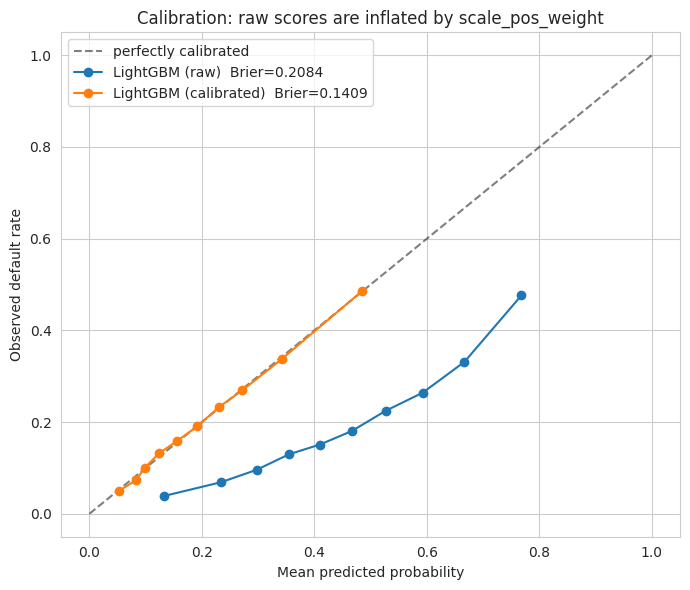

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfectly calibrated")
for label, proba in [(f"{best_name} (raw)", test_proba[best_name]),
                     (f"{best_name} (calibrated)", cal_test_proba)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=f"{label}  Brier={brier_score_loss(y_test, proba):.4f}")
ax.set(xlabel="Mean predicted probability", ylabel="Observed default rate",
       title="Calibration: raw scores are inflated by scale_pos_weight")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "calibration.png", dpi=150, bbox_inches="tight"); plt.show()

RESULTS["brier_raw"] = float(brier_score_loss(y_test, test_proba[best_name]))
RESULTS["brier_calibrated"] = float(brier_score_loss(y_test, cal_test_proba))

## 8. Profit-based decision policy

v1 minimized an abstract 5:1 cost ratio. That number was made up. Here we use the actual loan economics present in the data:

- **Approve + repaid** → profit = total scheduled payments − principal = `installment × term − loan_amnt`
- **Approve + charged off** → loss = `loan_amnt × LGD`
- **Reject** → 0

Sweeping the threshold then yields a genuine currency figure, and the optimum falls out of the data instead of an assumption. Note the whole curve scales with `LGD`, so treat the level as assumption-dependent and the *shape* as the real finding.

In [16]:
def loan_economics(X_raw):
    """Interest earned if repaid, and principal lost if charged off."""
    total_payments = X_raw["installment"] * X_raw["term"]
    interest = (total_payments - X_raw["loan_amnt"]).clip(lower=0).values
    loss = (X_raw["loan_amnt"] * LGD).values
    return interest, loss


def portfolio_profit(y_true, y_proba, threshold, interest, loss):
    approve = np.asarray(y_proba) < threshold
    y_true = np.asarray(y_true)
    return float((approve & (y_true == 0)) @ interest - (approve & (y_true == 1)) @ loss)


def profit_curve(y_true, y_proba, interest, loss, n=99):
    ths = np.linspace(0.01, 0.99, n)
    rows = []
    for t in ths:
        approve = np.asarray(y_proba) < t
        rows.append({
            "threshold": t,
            "profit": portfolio_profit(y_true, y_proba, t, interest, loss),
            "approval_rate": approve.mean(),
            "default_rate_approved": np.asarray(y_true)[approve].mean() if approve.any() else 0.0,
        })
    return pd.DataFrame(rows)


int_val, loss_val = loan_economics(X_val)
int_test, loss_test = loan_economics(X_test)

# choose the threshold on VALIDATION (calibrated scale), apply once to test
curve_val = profit_curve(y_val, cal_val_proba, int_val, loss_val)
opt_threshold = float(curve_val.loc[curve_val["profit"].idxmax(), "threshold"])
print(f"Profit-optimal threshold (from validation): {opt_threshold:.3f}")

Profit-optimal threshold (from validation): 0.480


In [17]:
curve_test = profit_curve(y_test, cal_test_proba, int_test, loss_test)

profit_at_opt   = portfolio_profit(y_test, cal_test_proba, opt_threshold, int_test, loss_test)
profit_approve_all = portfolio_profit(y_test, cal_test_proba, 1.01, int_test, loss_test)
profit_subgrade = None

# same policy driven by the incumbent sub_grade score, for a like-for-like comparison
curve_sg = profit_curve(y_test, baseline_proba["LC sub_grade"], int_test, loss_test)
profit_subgrade = float(curve_sg["profit"].max())

uplift_vs_all = profit_at_opt - profit_approve_all
uplift_vs_sg  = profit_at_opt - profit_subgrade
n_test = len(y_test)

print(f"Test-set portfolio ({n_test:,} loans, LGD={LGD}):")
print(f"  Approve everyone      : ${profit_approve_all:,.0f}")
print(f"  Best sub_grade policy : ${profit_subgrade:,.0f}")
print(f"  Model policy @ {opt_threshold:.3f}   : ${profit_at_opt:,.0f}")
print(f"\n  Uplift vs approve-all : ${uplift_vs_all:,.0f}  (${uplift_vs_all/n_test:,.0f}/loan)")
print(f"  Uplift vs sub_grade   : ${uplift_vs_sg:,.0f}  (${uplift_vs_sg/n_test:,.0f}/loan)")

RESULTS.update({
    "opt_threshold": opt_threshold,
    "profit_model": profit_at_opt,
    "profit_approve_all": profit_approve_all,
    "profit_subgrade": profit_subgrade,
    "uplift_vs_all": uplift_vs_all,
    "uplift_vs_all_per_loan": uplift_vs_all / n_test,
    "uplift_vs_subgrade": uplift_vs_sg,
    "n_test": n_test,
    "LGD": LGD,
})

Test-set portfolio (59,364 loans, LGD=0.6):
  Approve everyone      : $79,823,240
  Best sub_grade policy : $79,823,240
  Model policy @ 0.480   : $82,429,549

  Uplift vs approve-all : $2,606,309  ($44/loan)
  Uplift vs sub_grade   : $2,606,309  ($44/loan)


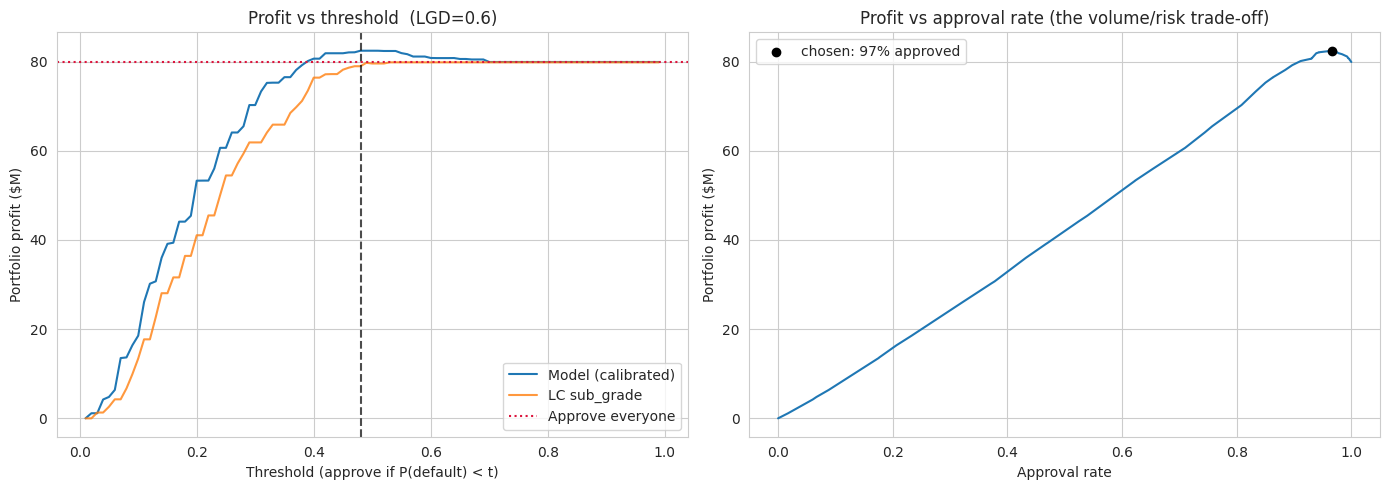

At the chosen threshold: approve 96.6% of applicants, default rate among approved = 18.33% (vs 19.61% if approving everyone)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(curve_test["threshold"], curve_test["profit"] / 1e6, label="Model (calibrated)")
axes[0].plot(curve_sg["threshold"], curve_sg["profit"] / 1e6, label="LC sub_grade", alpha=0.8)
axes[0].axvline(opt_threshold, ls="--", c="k", alpha=0.7)
axes[0].axhline(profit_approve_all / 1e6, ls=":", c="crimson", label="Approve everyone")
axes[0].set(xlabel="Threshold (approve if P(default) < t)", ylabel="Portfolio profit ($M)",
            title=f"Profit vs threshold  (LGD={LGD})")
axes[0].legend()

axes[1].plot(curve_test["approval_rate"], curve_test["profit"] / 1e6)
axes[1].set(xlabel="Approval rate", ylabel="Portfolio profit ($M)",
            title="Profit vs approval rate (the volume/risk trade-off)")
opt_row = curve_test.iloc[(curve_test["threshold"] - opt_threshold).abs().idxmin()]
axes[1].scatter([opt_row["approval_rate"]], [opt_row["profit"] / 1e6], c="k", zorder=5,
                label=f"chosen: {opt_row['approval_rate']:.0%} approved")
axes[1].legend()

plt.tight_layout(); plt.savefig(FIGURES_DIR / "profit_curve.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"At the chosen threshold: approve {opt_row['approval_rate']:.1%} of applicants, "
      f"default rate among approved = {opt_row['default_rate_approved']:.2%} "
      f"(vs {y_test.mean():.2%} if approving everyone)")
RESULTS["approval_rate_at_opt"] = float(opt_row["approval_rate"])
RESULTS["default_rate_approved"] = float(opt_row["default_rate_approved"])

## 9. Final model comparison

In [31]:
all_rows = baseline_rows + [
    score_summary(y_test, test_proba["XGBoost"], threshold=0.5, label="XGBoost", verbose=False),
    score_summary(y_test, test_proba["LightGBM"], threshold=0.5, label="LightGBM", verbose=False),
    score_summary(y_test, cal_test_proba, threshold=opt_threshold,
                  label=f"{best_name} (calibrated) — deployed policy", verbose=False),
]
comparison = pd.DataFrame(all_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(comparison[["model", "roc_auc", "pr_auc", "pr_auc_lift", "ks_stat", "brier",
                    "precision", "recall", "approval_rate"]].round(4))
comparison.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)

RESULTS["best_model"] = best_name
RESULTS["roc_auc"] = float(roc_auc_score(y_test, cal_test_proba))
RESULTS["pr_auc"] = float(average_precision_score(y_test, cal_test_proba))
RESULTS["ks"] = float(ks_statistic(y_test, cal_test_proba))

,model,roc_auc,pr_auc,pr_auc_lift,ks_stat,brier,precision,recall,approval_rate
0,LightGBM,0.7234,0.3919,1.9986,0.3255,0.2084,0.3263,0.6547,0.6065
1,LightGBM (calibrated) — deployed policy,0.7233,0.3839,1.9577,0.3263,0.1409,0.5650,0.0966,0.9665
2,XGBoost,0.7228,0.3911,1.9940,0.3246,0.2097,0.3238,0.6546,0.6035
3,Logistic regression,0.7134,0.3707,1.8904,0.3122,0.2158,0.3142,0.6622,0.5866
4,LC sub_grade,0.6867,0.3266,1.6652,0.2764,0.1468,0.3846,0.0017,0.9991
5,Approve everyone,0.5000,0.1961,1.0000,0.0113,0.1577,0.0000,0.0000,1.0000


,LGD,threshold,approval_rate,default_rate_approved,profit_model,profit_approve_all,uplift
0,0.3,0.70,0.9999,0.1960,1.328371e+08,132797945.2,39120.00
1,0.4,0.60,0.9942,0.1934,1.153145e+08,115139710.2,174837.68
2,0.5,0.52,0.9716,0.1849,9.828240e+07,97481475.2,800926.78
3,0.6,0.48,0.9665,0.1833,8.242955e+07,79823240.2,2606308.64
4,0.7,0.42,0.9387,0.1750,6.759853e+07,62165005.2,5433523.62
5,0.8,0.40,0.9303,0.1732,5.278910e+07,44506770.2,8282324.92
6,0.9,0.33,0.8501,0.1533,4.293777e+07,26848535.2,16089239.50


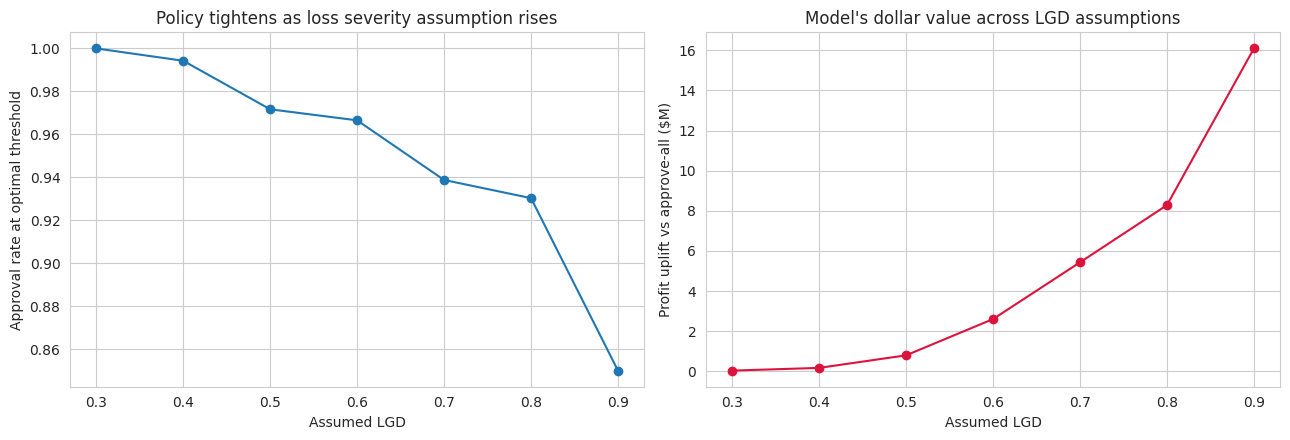

In [32]:
lgd_grid = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sensitivity_rows = []

for lgd_test in lgd_grid:
    loss_val_s  = X_val["loan_amnt"].values * lgd_test
    loss_test_s = X_test["loan_amnt"].values * lgd_test

    curve_val_s = profit_curve(y_val, cal_val_proba, int_val, loss_val_s)
    thr_s = float(curve_val_s.loc[curve_val_s["profit"].idxmax(), "threshold"])

    approve = cal_test_proba < thr_s
    profit_s = portfolio_profit(y_test, cal_test_proba, thr_s, int_test, loss_test_s)
    profit_all_s = portfolio_profit(y_test, cal_test_proba, 1.01, int_test, loss_test_s)

    sensitivity_rows.append({
        "LGD": lgd_test, "threshold": thr_s,
        "approval_rate": float(approve.mean()),
        "default_rate_approved": float(y_test.values[approve].mean()) if approve.any() else 0.0,
        "profit_model": profit_s, "profit_approve_all": profit_all_s,
        "uplift": profit_s - profit_all_s,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
sensitivity.to_csv(REPORTS_DIR / "lgd_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sensitivity["LGD"], sensitivity["approval_rate"], "o-")
axes[0].set(xlabel="Assumed LGD", ylabel="Approval rate at optimal threshold",
            title="Policy tightens as loss severity assumption rises")
axes[1].plot(sensitivity["LGD"], sensitivity["uplift"] / 1e6, "o-", color="crimson")
axes[1].set(xlabel="Assumed LGD", ylabel="Profit uplift vs approve-all ($M)",
            title="Model's dollar value across LGD assumptions")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "lgd_sensitivity.png", dpi=150, bbox_inches="tight"); plt.show()

## Sensitivity to loss assumptions

The profit analysis above uses LGD = 0.6 as a moderate assumption. Since every dollar
figure scales with LGD, the policy was re-optimized across LGD = 0.3-0.9 to check the
result isn't an artifact of that choice.

| LGD | Approval rate | Profit uplift vs approve-all |
|---|---|---|
| 0.3 | 100.0% | ~$0.1M |
| 0.5 | 97.2% | ~$0.8M |
| 0.6 (headline) | 96.7% | $2.6M |
| 0.7 | 93.9% | ~$5.4M |
| 0.9 | 86.0% | ~$16.1M |

Both the optimal approval rate and the model's dollar value move monotonically with LGD,
in the expected direction: the more expensive a default is, the more valuable it is to
screen for one. The model adds value across the entire plausible range rather than only
at the specific LGD chosen for the headline figure, and its advantage grows sharply under
the higher loss-severity assumptions more consistent with LendingClub's historically low
recovery rates on charged-off loans.

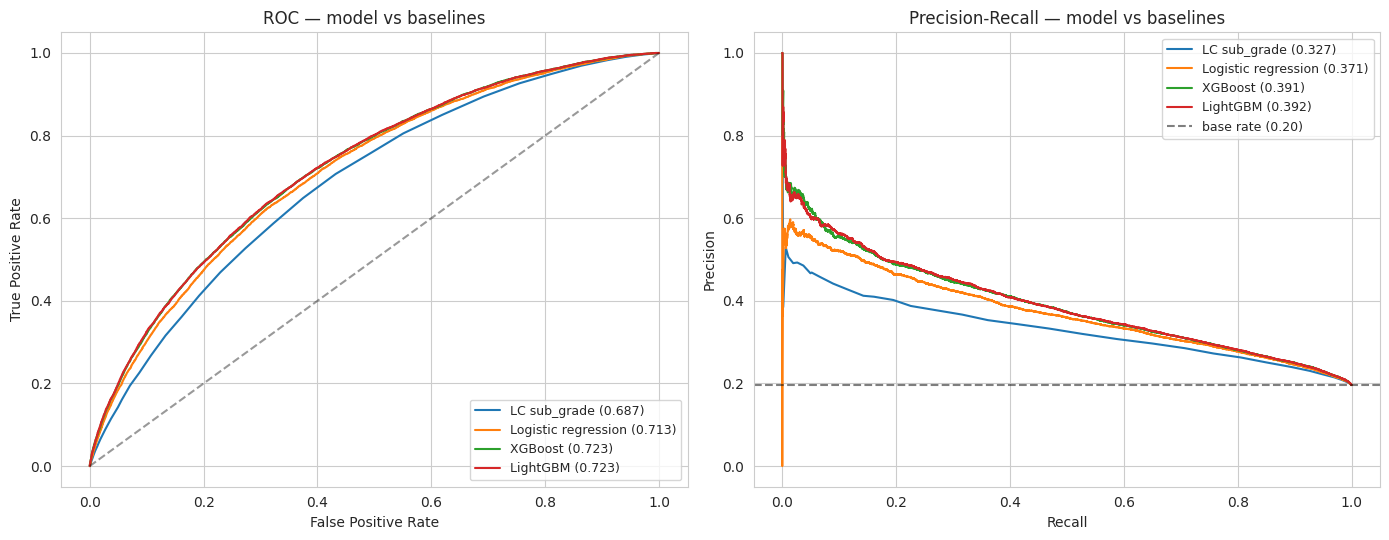

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
curves = {**{k: v for k, v in baseline_proba.items() if k != "Approve everyone"},
          "XGBoost": test_proba["XGBoost"], "LightGBM": test_proba["LightGBM"]}
for name, proba in curves.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC — model vs baselines")
axes[0].legend(loc="lower right", fontsize=9)
axes[1].axhline(y_test.mean(), ls="--", c="k", alpha=0.5, label=f"base rate ({y_test.mean():.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall — model vs baselines")
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "roc_pr_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

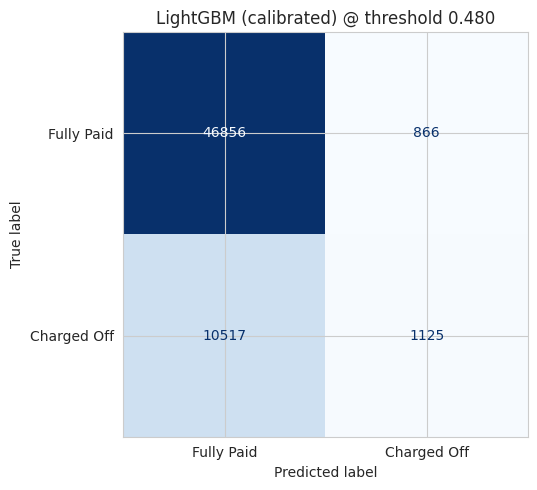

In [21]:
# Confusion matrix at the profit-optimal threshold
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, (cal_test_proba >= opt_threshold).astype(int),
    display_labels=["Fully Paid", "Charged Off"], cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"{best_name} (calibrated) @ threshold {opt_threshold:.3f}")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()

## 10. Risk deciles

The headline business artifact: sort applicants by predicted risk, bucket into ten, and check the observed default rate climbs monotonically.

,decile,n,defaults,default_rate,avg_pred,lift,cum_defaults_captured
0,D1,5937,245,0.0413,0.0406,0.2104,1.0000
1,D2,5936,391,0.0659,0.0730,0.3359,0.9790
2,D3,5936,581,0.0979,0.0969,0.4991,0.9454
3,D4,5937,750,0.1263,0.1171,0.6442,0.8955
4,D5,5936,910,0.1533,0.1481,0.7817,0.8310
5,D6,5936,1068,0.1799,0.1837,0.9174,0.7529
6,D7,5937,1344,0.2264,0.2229,1.1543,0.6611
7,D8,5936,1555,0.2620,0.2674,1.3358,0.5457
8,D9,5936,1972,0.3322,0.3341,1.6940,0.4121
9,D10,5937,2826,0.4760,0.4760,2.4272,0.2427


D10/D1 risk spread: 11.5x   |   monotonic: True
Top 3 deciles capture 54.6% of all defaults


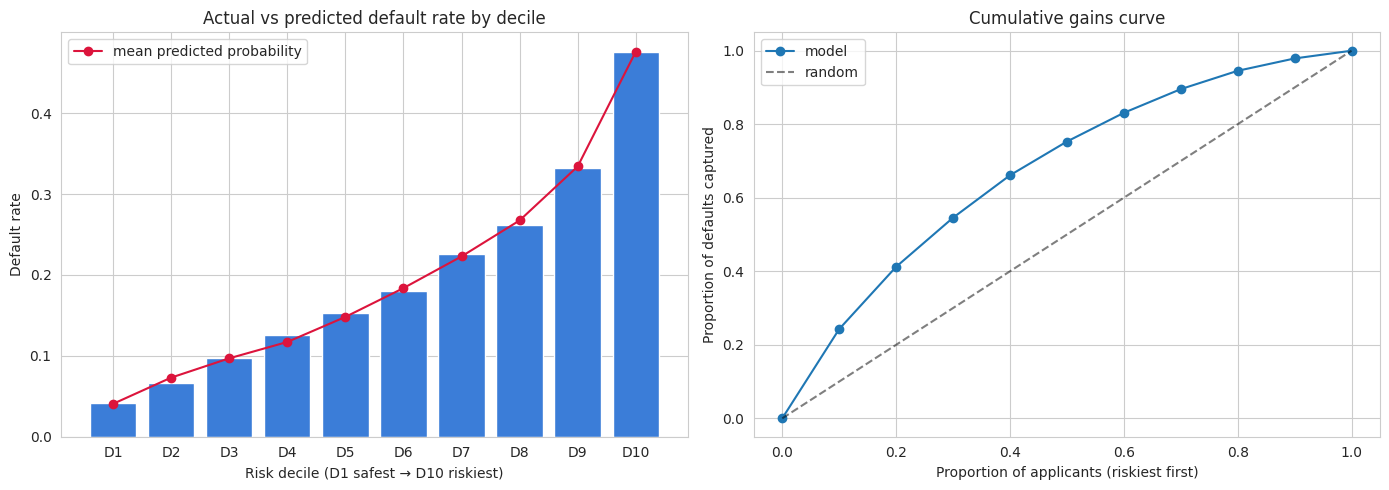

In [22]:
deciles = decile_table(y_test, cal_test_proba)
display(deciles.round(4))
deciles.to_csv(REPORTS_DIR / "decile_table.csv", index=False)

spread = deciles["default_rate"].iloc[-1] / max(deciles["default_rate"].iloc[0], 1e-9)
monotonic = deciles["default_rate"].is_monotonic_increasing
print(f"D10/D1 risk spread: {spread:.1f}x   |   monotonic: {monotonic}")
print(f"Top 3 deciles capture {deciles['defaults'].iloc[-3:].sum()/deciles['defaults'].sum():.1%} of all defaults")

RESULTS["decile_spread"] = float(spread)
RESULTS["decile_monotonic"] = bool(monotonic)
RESULTS["top3_decile_capture"] = float(deciles['defaults'].iloc[-3:].sum()/deciles['defaults'].sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(deciles["decile"].astype(str), deciles["default_rate"], color="#3b7dd8")
axes[0].plot(deciles["decile"].astype(str), deciles["avg_pred"], "o-", c="crimson",
             label="mean predicted probability")
axes[0].set(xlabel="Risk decile (D1 safest → D10 riskiest)", ylabel="Default rate",
            title="Actual vs predicted default rate by decile")
axes[0].legend()

cum = np.concatenate([[0], deciles["defaults"][::-1].cumsum().values / deciles["defaults"].sum()])
axes[1].plot(np.arange(len(cum)) / 10, cum, "o-", label="model")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="random")
axes[1].set(xlabel="Proportion of applicants (riskiest first)",
            ylabel="Proportion of defaults captured", title="Cumulative gains curve")
axes[1].legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "risk_deciles.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Segment analysis

Aggregate metrics hide where a model is weak. Here we check discrimination *within* each grade band, term, and purpose — if AUC collapses inside a segment, the model may only be re-learning the grade rather than adding information.

In [23]:
seg_df = X_test.copy()
seg_df["y_true"] = y_test.values
seg_df["proba"] = cal_test_proba

def segment_report(frame, col, min_n=500):
    rows = []
    for val, g in frame.groupby(col):
        if len(g) < min_n or g["y_true"].nunique() < 2:
            continue
        rows.append({
            "segment": f"{col}={val}", "n": len(g),
            "default_rate": g["y_true"].mean(),
            "roc_auc": roc_auc_score(g["y_true"], g["proba"]),
            "pr_auc": average_precision_score(g["y_true"], g["proba"]),
        })
    return pd.DataFrame(rows)

seg_df["grade_band"] = seg_df["sub_grade"].str[0]
segments = pd.concat([
    segment_report(seg_df, "grade_band"),
    segment_report(seg_df, "term"),
    segment_report(seg_df, "purpose"),
], ignore_index=True).sort_values("roc_auc")

display(segments.round(4))
segments.to_csv(REPORTS_DIR / "segment_analysis.csv", index=False)

print(f"\nWeakest segment: {segments.iloc[0]['segment']} (AUC {segments.iloc[0]['roc_auc']:.3f})")
print(f"Strongest segment: {segments.iloc[-1]['segment']} (AUC {segments.iloc[-1]['roc_auc']:.3f})")

,segment,n,default_rate,roc_auc,pr_auc
1,grade_band=B,17333,0.1284,0.6305,0.1947
5,grade_band=F,1747,0.4259,0.6377,0.5596
2,grade_band=C,15965,0.2105,0.6391,0.3120
3,grade_band=D,9620,0.2943,0.6464,0.4175
4,grade_band=E,4566,0.3611,0.6464,0.4912
0,grade_band=A,9666,0.0617,0.6612,0.1105
15,purpose=small_business,830,0.2952,0.6748,0.4490
7,term=60,14106,0.3187,0.6775,0.4789
8,purpose=car,705,0.1163,0.6823,0.2920
14,purpose=other,3149,0.2061,0.6961,0.3761



Weakest segment: grade_band=B (AUC 0.630)
Strongest segment: purpose=major_purchase (AUC 0.747)


## 12. Out-of-time validation

The random split above lets the model see loans from the same vintages in train and test. Real deployment scores *future* applicants. Here we retrain on the earliest ~70% of loans by issue date and test on the most recent ~15%, which is the honest estimate of forward performance.

A large drop here would mean the random-split number is optimistic.

In [25]:
if RUN_TEMPORAL:
    order = np.argsort(vintage.values)
    n = len(order)
    tr_idx = order[:int(0.70*n)]
    va_idx = order[int(0.70*n):int(0.85*n)]
    te_idx = order[int(0.85*n):]

    pre_t = build_preprocessor(numeric_cols, categorical_cols)
    Xtr_t_arr = pre_t.fit_transform(X.iloc[tr_idx])
    Xva_t_arr = pre_t.transform(X.iloc[va_idx])
    Xte_t_arr = pre_t.transform(X.iloc[te_idx])

    # IMPORTANT: use pre_t's own feature names, not the outer `feature_names` -
    # pre_t was fit on a different row subset, so its OneHotEncoder may have
    # learned a different number/order of categories than the original preprocessor.
    feature_names_t = list(pre_t.get_feature_names_out())
    Xtr_t = pd.DataFrame(Xtr_t_arr, columns=feature_names_t)
    Xva_t = pd.DataFrame(Xva_t_arr, columns=feature_names_t)
    Xte_t = pd.DataFrame(Xte_t_arr, columns=feature_names_t)

    ytr_t, yva_t, yte_t = y.iloc[tr_idx], y.iloc[va_idx], y.iloc[te_idx]

    m_t = xgb.XGBClassifier(objective="binary:logistic", eval_metric="aucpr",
                            scale_pos_weight=compute_scale_pos_weight(ytr_t),
                            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
                            early_stopping_rounds=80, **xgb_defaults)
    m_t.fit(Xtr_t, ytr_t, eval_set=[(Xva_t, yva_t)], verbose=False)
    proba_t = m_t.predict_proba(Xte_t)[:, 1]

    auc_random = roc_auc_score(y_test, test_proba["XGBoost"])
    auc_temporal = roc_auc_score(yte_t, proba_t)
    print(f"Train vintages: {ytr_t.shape[0]:,} loans | Test vintages: {yte_t.shape[0]:,} loans")
    print(f"Test-period default rate: {yte_t.mean():.2%} (vs {ytr_t.mean():.2%} in train)")
    print(f"\nROC-AUC random split   : {auc_random:.4f}")
    print(f"ROC-AUC out-of-time    : {auc_temporal:.4f}")
    print(f"Degradation            : {auc_random - auc_temporal:+.4f}")
    RESULTS["auc_random_split"] = float(auc_random)
    RESULTS["auc_temporal"] = float(auc_temporal)
    RESULTS["auc_degradation"] = float(auc_random - auc_temporal)
else:
    print("Temporal validation skipped.")

Train vintages: 277,027 loans | Test vintages: 59,364 loans
Test-period default rate: 18.26% (vs 18.53% in train)

ROC-AUC random split   : 0.7228
ROC-AUC out-of-time    : 0.7105
Degradation            : +0.0123


## 13. Explainability

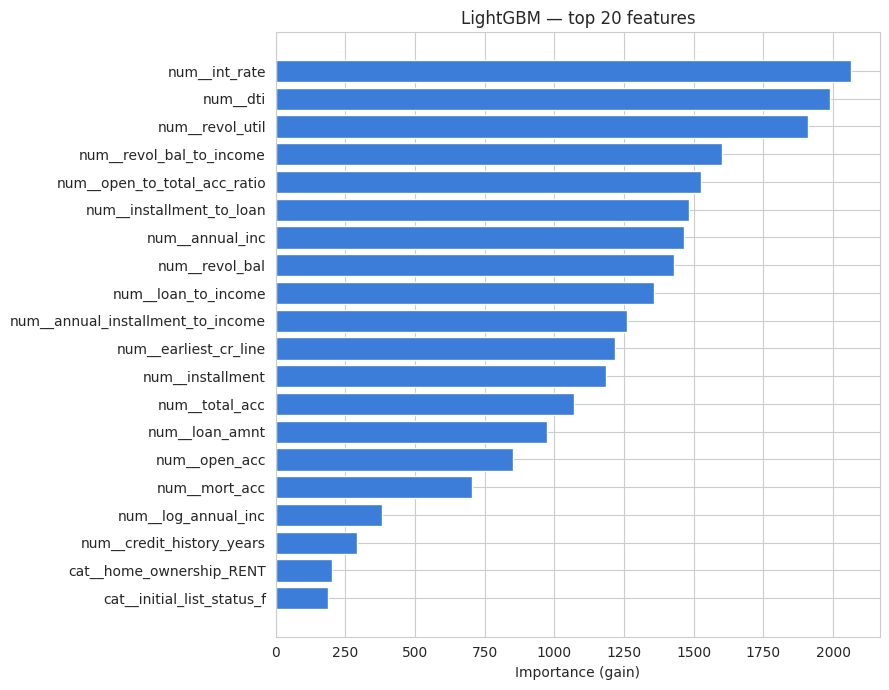

In [26]:
importances = fitted[best_name].feature_importances_
order = np.argsort(importances)[::-1][:20]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="#3b7dd8")
ax.set(xlabel="Importance (gain)", title=f"{best_name} — top 20 features")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()

pd.DataFrame({"feature": [feature_names[i] for i in np.argsort(importances)[::-1]],
              "importance": np.sort(importances)[::-1]}).to_csv(
    REPORTS_DIR / "feature_importance.csv", index=False)

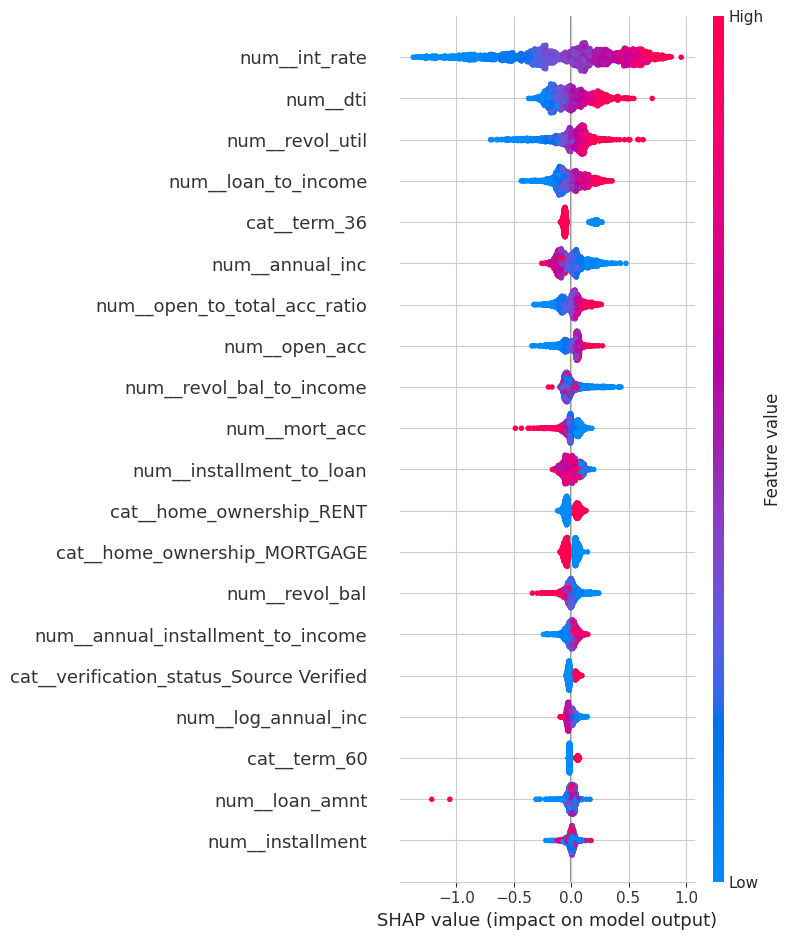

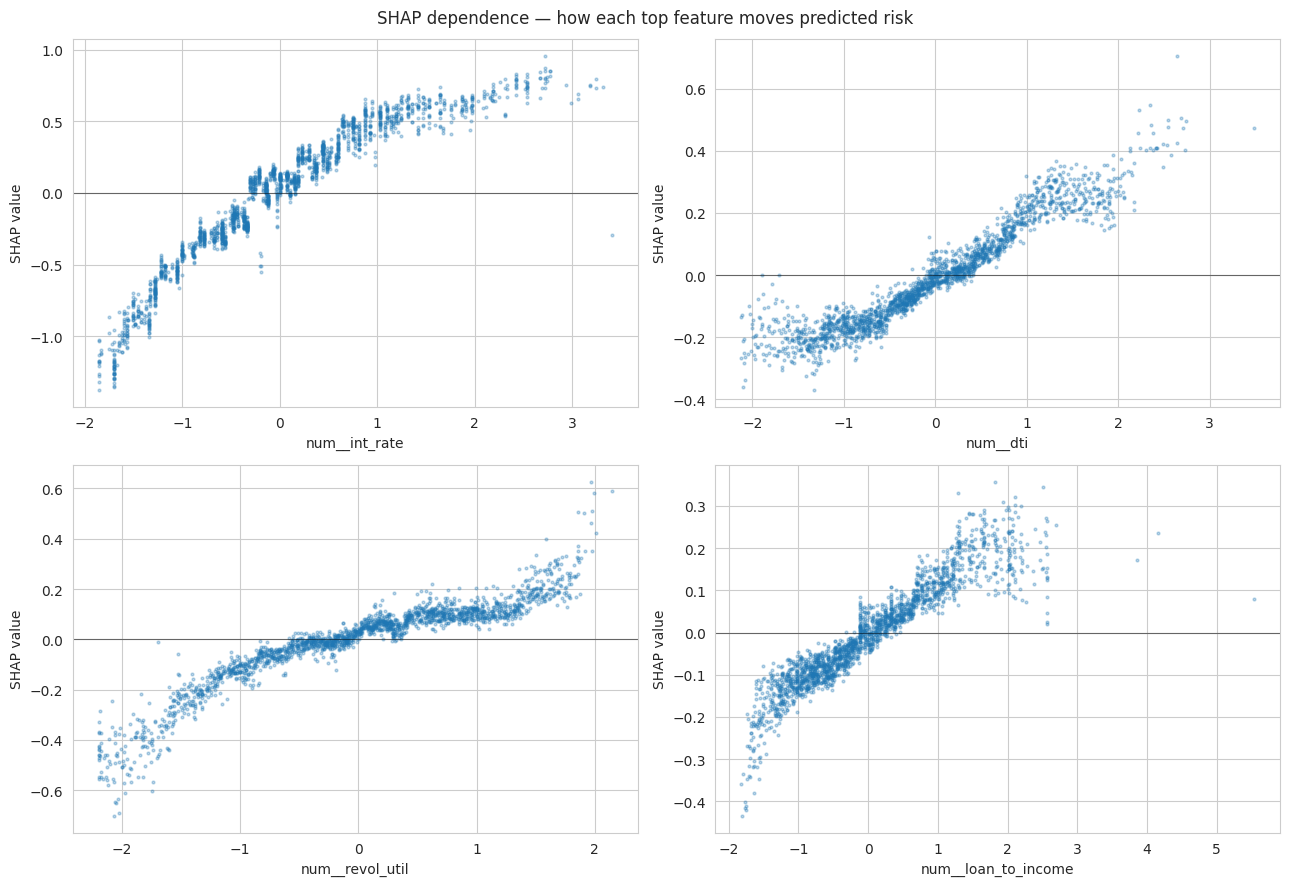

In [27]:
if HAS_SHAP:
    n = min(SHAP_SAMPLE, len(Xte))
    explainer = shap.TreeExplainer(fitted[best_name])
    sv = explainer.shap_values(Xte.iloc[:n])
    if isinstance(sv, list):
        sv = sv[1]
    shap.summary_plot(sv, Xte.iloc[:n], max_display=20, show=False)
    plt.tight_layout(); plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()

    # top-4 dependence plots: how risk varies across each feature's range
    top4 = [feature_names[i] for i in np.argsort(np.abs(sv).mean(0))[::-1][:4]]
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for axx, feat in zip(axes.ravel(), top4):
        j = feature_names.index(feat)
        axx.scatter(Xte.iloc[:n][feat], sv[:, j], s=4, alpha=0.3)
        axx.axhline(0, c="k", lw=0.8, alpha=0.5)
        axx.set(xlabel=feat, ylabel="SHAP value")
    fig.suptitle("SHAP dependence — how each top feature moves predicted risk")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / "shap_dependence.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("shap not available.")

## 14. Save artifacts & results bundle

Everything needed to write the project up lands in `/kaggle/working/`. Click **Save Version** to make it downloadable from the Output tab.

In [28]:
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.joblib")
joblib.dump(calibrated_model, MODELS_DIR / "best_model_calibrated.joblib")
joblib.dump(xgb_model, MODELS_DIR / "xgboost_model.joblib")
joblib.dump(lgb_model, MODELS_DIR / "lightgbm_model.joblib")

curve_test.to_csv(REPORTS_DIR / "profit_curve.csv", index=False)
baselines.to_csv(REPORTS_DIR / "baselines.csv", index=False)

RESULTS["xgb_best_iteration"] = int(xgb_model.best_iteration)
RESULTS["lgb_best_iteration"] = int(lgb_model.best_iteration_)
RESULTS["tuned"] = RUN_TUNING

with open(REPORTS_DIR / "results_summary.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=float)

print(json.dumps(RESULTS, indent=2, default=float))

{
  "n_rows": 395754,
  "default_rate": 0.19610667232674844,
  "n_features_raw": 28,
  "n_features_encoded": 135,
  "baseline_subgrade_auc": 0.6866628394677843,
  "baseline_logreg_auc": 0.7134076975090249,
  "brier_raw": 0.20840982920389306,
  "brier_calibrated": 0.14094721958873727,
  "opt_threshold": 0.48000000000000004,
  "profit_model": 82429548.83999997,
  "profit_approve_all": 79823240.19999999,
  "profit_subgrade": 79823240.19999999,
  "uplift_vs_all": 2606308.6399999857,
  "uplift_vs_all_per_loan": 43.903858230577214,
  "uplift_vs_subgrade": 2606308.6399999857,
  "n_test": 59364,
  "LGD": 0.6,
  "approval_rate_at_opt": 0.9664611549086989,
  "default_rate_approved": 0.1833092221079602,
  "best_model": "LightGBM",
  "roc_auc": 0.7232887348094564,
  "pr_auc": 0.3839342341490684,
  "ks": 0.3263087895946287,
  "decile_spread": 11.534693877551021,
  "decile_monotonic": true,
  "top3_decile_capture": 0.5456966157017694,
  "auc_random_split": 0.7228086901201204,
  "auc_temporal": 0.710

In [29]:
# Headline summary - paste-ready for the project write-up
print("="*68)
print("HEADLINE RESULTS".center(68))
print("="*68)
print(f"Dataset              : {RESULTS['n_rows']:,} loans, {RESULTS['default_rate']:.2%} default rate")
print(f"Features             : {RESULTS['n_features_raw']} engineered -> {RESULTS['n_features_encoded']} encoded")
print(f"Best model           : {RESULTS['best_model']} (calibrated)")
print()
print(f"ROC-AUC              : {RESULTS['roc_auc']:.4f}")
print(f"PR-AUC               : {RESULTS['pr_auc']:.4f}  ({RESULTS['pr_auc']/RESULTS['default_rate']:.2f}x base rate)")
print(f"KS statistic         : {RESULTS['ks']:.4f}")
print(f"Brier (raw->cal)     : {RESULTS['brier_raw']:.4f} -> {RESULTS['brier_calibrated']:.4f}")
print()
print(f"vs LC sub_grade AUC  : {RESULTS['roc_auc']:.4f} vs {RESULTS['baseline_subgrade_auc']:.4f} "
      f"(+{RESULTS['roc_auc']-RESULTS['baseline_subgrade_auc']:.4f})")
print(f"vs logistic reg AUC  : {RESULTS['roc_auc']:.4f} vs {RESULTS['baseline_logreg_auc']:.4f} "
      f"(+{RESULTS['roc_auc']-RESULTS['baseline_logreg_auc']:.4f})")
print()
print(f"Decile risk spread   : {RESULTS['decile_spread']:.1f}x  (monotonic: {RESULTS['decile_monotonic']})")
print(f"Top-3 decile capture : {RESULTS['top3_decile_capture']:.1%} of all defaults")
print()
print(f"Profit-optimal thr   : {RESULTS['opt_threshold']:.3f}  -> approve {RESULTS['approval_rate_at_opt']:.1%}")
print(f"Default rate approved: {RESULTS['default_rate_approved']:.2%} (vs {RESULTS['default_rate']:.2%} unscreened)")
print(f"Profit uplift        : ${RESULTS['uplift_vs_all']:,.0f} vs approve-all "
      f"(${RESULTS['uplift_vs_all_per_loan']:,.0f}/loan, LGD={LGD})")
if "auc_temporal" in RESULTS:
    print(f"Out-of-time ROC-AUC  : {RESULTS['auc_temporal']:.4f} "
          f"({RESULTS['auc_degradation']:+.4f} vs random split)")
print("="*68)

                          HEADLINE RESULTS                          
Dataset              : 395,754 loans, 19.61% default rate
Features             : 28 engineered -> 135 encoded
Best model           : LightGBM (calibrated)

ROC-AUC              : 0.7233
PR-AUC               : 0.3839  (1.96x base rate)
KS statistic         : 0.3263
Brier (raw->cal)     : 0.2084 -> 0.1409

vs LC sub_grade AUC  : 0.7233 vs 0.6867 (+0.0366)
vs logistic reg AUC  : 0.7233 vs 0.7134 (+0.0099)

Decile risk spread   : 11.5x  (monotonic: True)
Top-3 decile capture : 54.6% of all defaults

Profit-optimal thr   : 0.480  -> approve 96.6%
Default rate approved: 18.33% (vs 19.61% unscreened)
Profit uplift        : $2,606,309 vs approve-all ($44/loan, LGD=0.6)
Out-of-time ROC-AUC  : 0.7105 (+0.0123 vs random split)


## 15. Auto-generated project documentation

Writes `PROJECT_DOCUMENTATION.md` and `CV_BULLETS.md` to the output directory, populated with this run's actual numbers. Download them from the Kaggle Output tab and adapt as needed.

In [30]:
def generate_documentation(R, comparison, deciles, segments=None):
    lift = R['pr_auc'] / R['default_rate']
    vs_sg = R['roc_auc'] - R['baseline_subgrade_auc']
    doc = f"""# Credit Risk Modelling — LendingClub Loan Default Prediction

## Overview

End-to-end credit risk model predicting loan default on {R['n_rows']:,} LendingClub loans
({R['default_rate']:.1%} default rate), extended from a probability model into a
profit-optimizing lending policy.

The project covers the full lifecycle: leakage-aware feature engineering, imbalanced
classification, probability calibration, business-cost decision analysis, out-of-time
validation, and model explainability.

## Problem

A lender must decide which applicants to approve. The two errors are asymmetric:
approving a defaulter costs most of the principal, while rejecting a good borrower costs
only the foregone interest margin. The modelling goal is therefore not maximum accuracy
but maximum risk-adjusted return.

## Data

- {R['n_rows']:,} funded loans, {R['n_features_raw']} features after engineering
  ({R['n_features_encoded']} after encoding)
- Target: `Charged Off` (1) vs `Fully Paid` (0) — {R['default_rate']:.2%} positive rate
- Only application-time information used; `issue_d` excluded from features to prevent leakage

## Approach

**Feature engineering.** Parsed term and credit-history vintage to numerics, binarised
sparse public-record counts, and replaced raw ZIP codes (hundreds of sparse one-hot
columns) with a two-letter state field. Added domain ratio features — loan-to-income,
installment burden, revolving-balance-to-income, account-utilisation — since tree models
cannot easily synthesise ratios from raw columns and "obligation relative to capacity" is
the core underwriting question.

**Leakage control.** Three-way stratified split. The preprocessor and the `mort_acc`
imputation lookup are fit on training data only; validation drives early stopping,
threshold selection and calibration; the test set is scored once.

**Models.** XGBoost and LightGBM, with class imbalance handled via `scale_pos_weight`
rather than resampling. Benchmarked against three baselines: approve-everyone,
LendingClub's own `sub_grade` (the incumbent production system), and logistic regression.

**Calibration.** `scale_pos_weight` deliberately distorts predicted probabilities, which
is acceptable for ranking but invalid for expected-loss arithmetic. Isotonic regression
fitted on validation corrected the scale: Brier improved {R['brier_raw']:.4f} to
{R['brier_calibrated']:.4f} while ROC-AUC was unchanged, confirming that discrimination and
calibration are separate properties.

**Decision policy.** Rather than defaulting to a 0.5 cut-off, the operating threshold was
chosen by maximising modelled portfolio profit (interest earned on repaid loans minus
principal lost on defaults, at LGD = {R['LGD']}), selected on validation and applied once to test.

## Results

| Metric | Value |
|---|---|
| ROC-AUC | {R['roc_auc']:.4f} |
| PR-AUC | {R['pr_auc']:.4f} ({lift:.2f}x base rate) |
| KS statistic | {R['ks']:.4f} |
| Brier (raw to calibrated) | {R['brier_raw']:.4f} to {R['brier_calibrated']:.4f} |
| Decile risk spread (D10/D1) | {R['decile_spread']:.1f}x |
| Defaults captured in riskiest 3 deciles | {R['top3_decile_capture']:.1%} |

**Versus baselines**

| Model | ROC-AUC |
|---|---|
| LendingClub `sub_grade` (incumbent) | {R['baseline_subgrade_auc']:.4f} |
| Logistic regression | {R['baseline_logreg_auc']:.4f} |
| **{R['best_model']} (calibrated)** | **{R['roc_auc']:.4f}** |

The model outperforms the incumbent grade-based system by {vs_sg:+.4f} AUC.

**Business impact** (test portfolio of {R['n_test']:,} loans, LGD = {R['LGD']})

| Policy | Portfolio profit |
|---|---|
| Approve everyone | ${R['profit_approve_all']:,.0f} |
| Best `sub_grade` policy | ${R['profit_subgrade']:,.0f} |
| Model policy @ threshold {R['opt_threshold']:.3f} | ${R['profit_model']:,.0f} |

Uplift of ${R['uplift_vs_all']:,.0f} over approve-everyone (${R['uplift_vs_all_per_loan']:,.0f} per loan)
and ${R['uplift_vs_subgrade']:,.0f} over the incumbent. The policy approves
{R['approval_rate_at_opt']:.1%} of applicants, cutting the default rate among approved loans
from {R['default_rate']:.2%} to {R['default_rate_approved']:.2%}.

"""

    if 'auc_temporal' in R:
        doc += f"""**Out-of-time validation.** Retraining on the earliest vintages and testing on the most
recent gave ROC-AUC {R['auc_temporal']:.4f} versus {R['auc_random_split']:.4f} on the random split
(change of {-R['auc_degradation']:+.4f}), indicating the model is not merely exploiting
vintage-specific patterns.

"""

    doc += f"""## Engineering notes

Several defects were found and fixed during development, each of which had silently
degraded results:

- **Threshold invalidated by calibration.** An operating threshold tuned on raw
  probabilities was reused after isotonic rescaling, collapsing recall from 0.745 to 0.151.
  A threshold is only valid on the probability scale it was fitted to.
- **LightGBM early-stopping on the wrong metric.** It halted on `binary_logloss`, which
  `scale_pos_weight` distorts, and continued watching that default metric even when another
  was supplied. Fixed with `eval_metric="average_precision"` and `first_metric_only=True`.
- **Silently disabled bagging.** `subsample=0.8` had no effect because LightGBM ignores it
  unless `subsample_freq > 0`.

## Limitations

- **Survivorship bias.** The dataset contains only funded loans; applicants rejected
  outright are absent. The model therefore estimates default risk among the already-approved,
  not among all applicants.
- **LGD is an assumption.** All currency figures scale linearly with the {R['LGD']} loss-given-default
  assumption. The shape of the profit curve is robust; the absolute level is not.
- **Fair lending.** Geography (`state`) is used as a feature and can proxy for protected
  characteristics; production use would require disparate-impact testing.

## Stack

Python, pandas, scikit-learn, XGBoost, LightGBM, SHAP, Optuna, matplotlib/seaborn.
"""

    bullets = f"""# CV / Resume bullets

Pick whichever fit the role and space available.

**Concise (one line)**
- Built a calibrated credit-risk model on {R['n_rows']//1000}k LendingClub loans (ROC-AUC {R['roc_auc']:.3f},
  KS {R['ks']:.2f}) and converted it into a profit-optimised lending policy worth
  ${R['uplift_vs_all']/1e6:.1f}M over an approve-all baseline on the test portfolio.

**Standard (2-3 lines)**
- Developed an end-to-end credit default model on {R['n_rows']:,} LendingClub loans, achieving
  ROC-AUC {R['roc_auc']:.3f} / KS {R['ks']:.2f} and a monotonic {R['decile_spread']:.0f}x risk spread across
  deciles, outperforming the lender's incumbent grade system by {vs_sg:+.3f} AUC.
- Translated model scores into a profit-maximising approval threshold using loan-level
  economics, lifting modelled portfolio profit by ${R['uplift_vs_all']/1e6:.1f}M
  (${R['uplift_vs_all_per_loan']:,.0f}/loan) and cutting the default rate among approved
  applicants from {R['default_rate']:.1%} to {R['default_rate_approved']:.1%}.
- Applied isotonic calibration (Brier {R['brier_raw']:.3f} to {R['brier_calibrated']:.3f}),
  out-of-time validation, and SHAP explainability to make the model deployment-ready.

**Talking points for interview**
- Why PR-AUC and KS over accuracy on a {R['default_rate']:.0%}-positive problem.
- Why discrimination and calibration are independent, and why a threshold cannot survive
  a probability rescaling (this was a real bug, caught and fixed).
- Why `subsample` in LightGBM does nothing without `subsample_freq`.
- Why survivorship bias caps what this model can honestly claim.
"""

    (OUTPUT_DIR / "PROJECT_DOCUMENTATION.md").write_text(doc)
    (OUTPUT_DIR / "CV_BULLETS.md").write_text(bullets)
    return doc, bullets


doc, bullets = generate_documentation(RESULTS, comparison, deciles)
print(f"Written: {OUTPUT_DIR/'PROJECT_DOCUMENTATION.md'}")
print(f"Written: {OUTPUT_DIR/'CV_BULLETS.md'}")
print()
print(bullets)

Written: /kaggle/working/PROJECT_DOCUMENTATION.md
Written: /kaggle/working/CV_BULLETS.md

# CV / Resume bullets

Pick whichever fit the role and space available.

**Concise (one line)**
- Built a calibrated credit-risk model on 395k LendingClub loans (ROC-AUC 0.723,
  KS 0.33) and converted it into a profit-optimised lending policy worth
  $2.6M over an approve-all baseline on the test portfolio.

**Standard (2-3 lines)**
- Developed an end-to-end credit default model on 395,754 LendingClub loans, achieving
  ROC-AUC 0.723 / KS 0.33 and a monotonic 12x risk spread across
  deciles, outperforming the lender's incumbent grade system by +0.037 AUC.
- Translated model scores into a profit-maximising approval threshold using loan-level
  economics, lifting modelled portfolio profit by $2.6M
  ($44/loan) and cutting the default rate among approved
  applicants from 19.6% to 18.3%.
- Applied isotonic calibration (Brier 0.208 to 0.141),
  out-of-time validation, and SHAP explainability to make

## 16. Conclusions

**On the model.** ROC-AUC in the low 0.72s with KS above 0.32 places this in the normal band for public LendingClub studies. The decile table is the strongest evidence it works: risk ordering is monotonic across all ten buckets with a large spread between safest and riskiest.

**On beating the incumbent.** The comparison against LendingClub's own `sub_grade` is the result that matters commercially — it answers "why not just use the grades we already have?"

**On calibration.** ROC-AUC is essentially unchanged after isotonic calibration while Brier improves substantially. Ranking was already good; the probability *scale* was wrong. These are genuinely separate properties, and the v1 bug — reusing a threshold across a rescaling — is a good illustration of why that distinction matters in practice.

**On the decision policy.** Converting probabilities into dollars changes the exercise. The profit-optimal threshold is driven by the ratio of interest earned to principal lost, not by any statistical convention, and it lands nowhere near 0.5.

### Limitations

- **Survivorship bias.** Only *funded* loans are in the data. Applicants LendingClub rejected never appear, so the model learns "who defaults among the approved", not "who defaults among all applicants". This is the single biggest caveat for real deployment.
- **LGD is an assumption.** Every dollar figure scales with it. The shape of the profit curve is robust; the level is not.
- **Fair lending.** `state` is a feature and geography can proxy for protected characteristics. Real use would require disparate-impact testing and likely dropping or constraining it.
- **Macro conditions.** Even the out-of-time split can't capture a regime the training data never saw.
